In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr
#import gsw

In [55]:
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

emulator_path = '/orcd/data/abodner/002/cody/inference_patch/predictions/2026-04-06-eval:samudra_llc:Agulhas,from-4-4-26-RESUME/predictions_4d.zarr'#'/orcd/data/abodner/002/cody/inference_patch/predictions/2026-03-26-eval:samudra_llc:epoch1_oct2012_patchloc=i(2880,3600)-j(720,1440)/predictions_4d.zarr'
emulator_patch_full = xr.open_dataset(emulator_path, consolidated=True)
#emulator_patch_full = xr.open_dataset(llc_path, consolidated=True)

In [56]:
#9216,9960

In [57]:
extent = 9960 - 9216
llc_patch = llc_patch_full.isel(time=slice(9958, 9960))
emulator_patch = emulator_patch_full.isel(time=slice(740, 742))#(9216, 9216 + extent))#(0, extent))

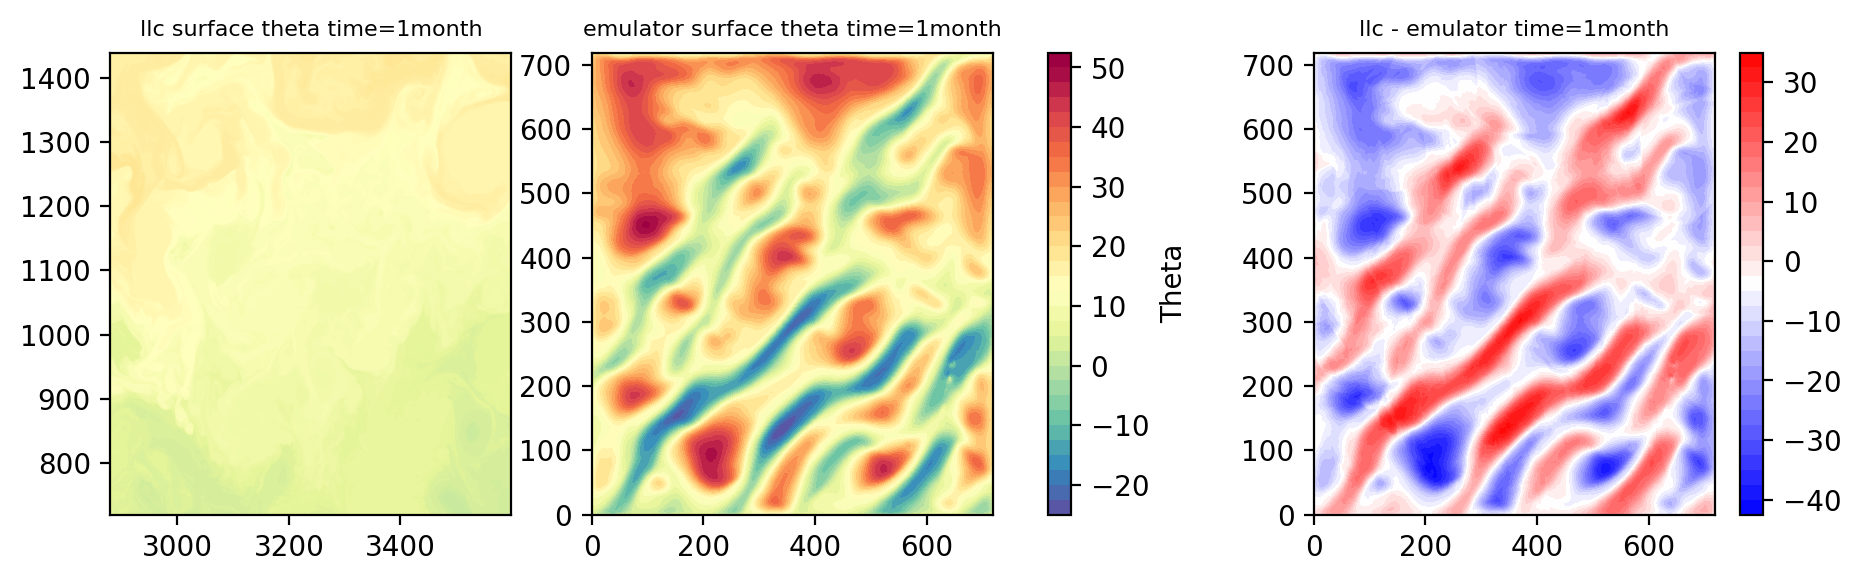

In [58]:
llc_vis = llc_patch.isel(time=1,k=0).Theta
emulator_vis = emulator_patch.isel(time=1,k=0).Theta

# Get shared vmin/vmax for llc and emulator
vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="Spectral_r", vmin=vmin, vmax=vmax, levels = 30)
ax1.set_title('llc surface theta time=1month', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="Spectral_r", vmin=vmin, vmax=vmax, levels = 30)
ax2.set_title('emulator surface theta time=1month', fontsize=8)

# Single colorbar for ax1 and ax2
cbar = plt.colorbar(cf2, ax=[ax1, ax2])
cbar.set_label('Theta')

diff = llc_vis.values - emulator_vis.values
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="bwr", levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1month', fontsize=8)

#plt.tight_layout()
plt.show()

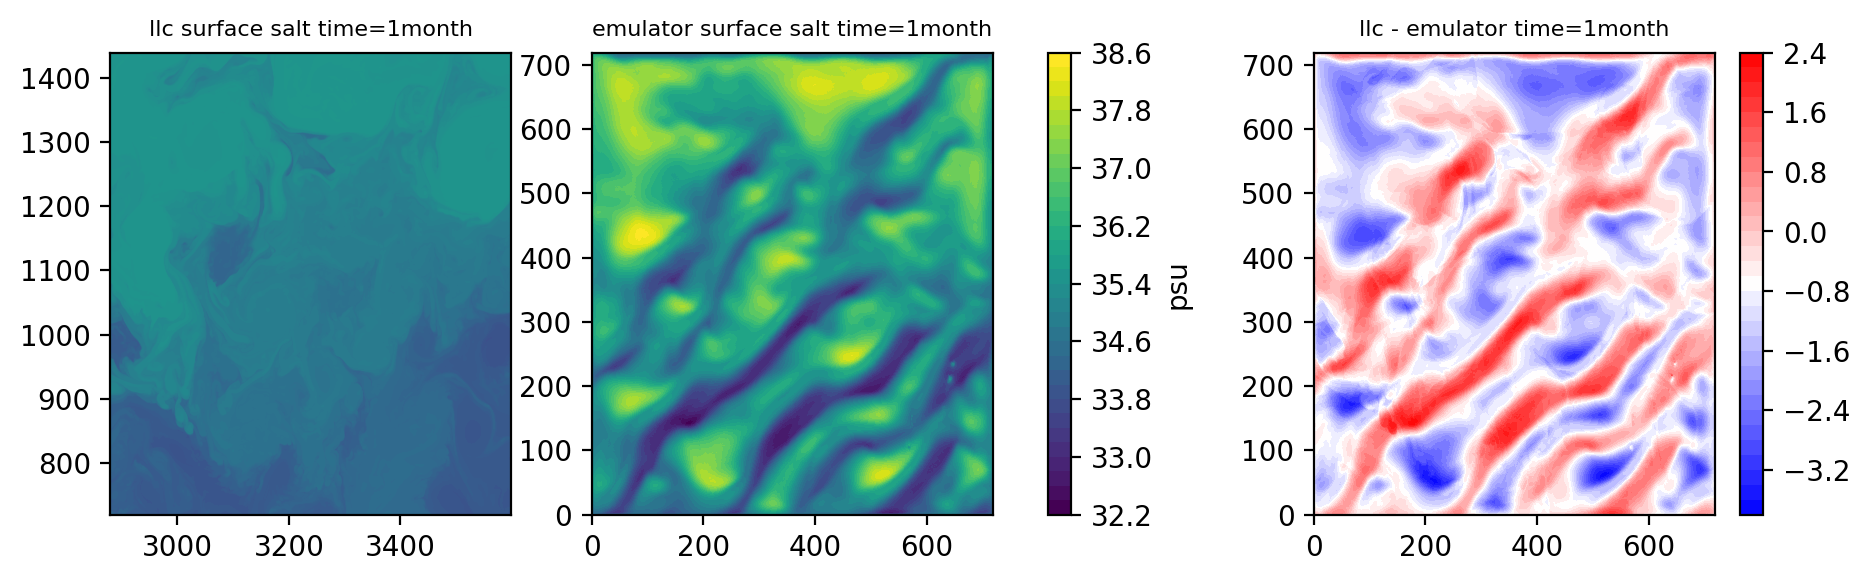

In [59]:
llc_vis = llc_patch.isel(time=1,k=0).Salt
emulator_vis = emulator_patch.isel(time=1,k=0).Salt

# Get shared vmin/vmax for llc and emulator
vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="viridis", vmin=vmin, vmax=vmax, levels = 30)
ax1.set_title('llc surface salt time=1month', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="viridis", vmin=vmin, vmax=vmax, levels = 30)
ax2.set_title('emulator surface salt time=1month', fontsize=8)

# Single colorbar for ax1 and ax2
cbar = plt.colorbar(cf2, ax=[ax1, ax2])
cbar.set_label('psu')

diff = llc_vis.values - emulator_vis.values
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="bwr", levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1month', fontsize=8)

#plt.tight_layout()
plt.show()

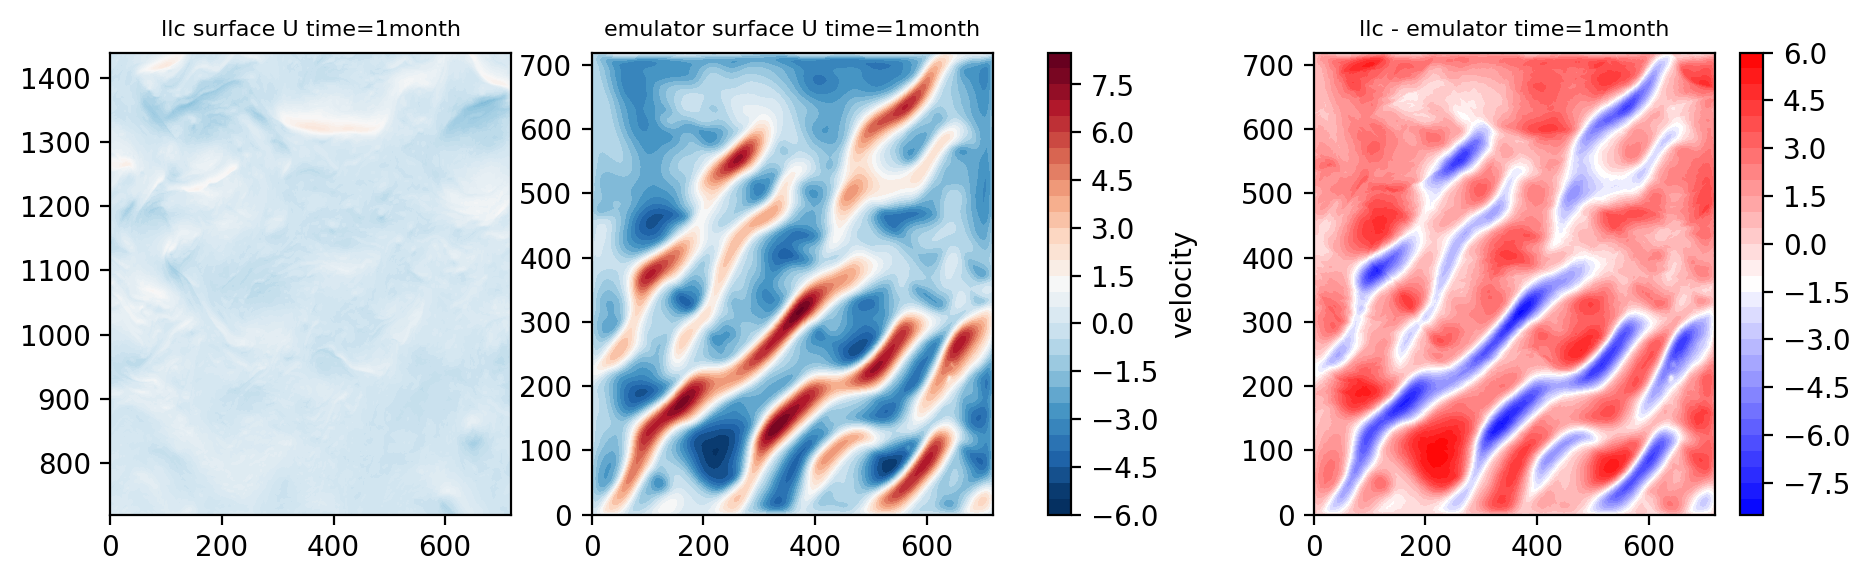

In [8]:
llc_vis = llc_patch.isel(time=1,k=0).U
emulator_vis = emulator_patch.isel(time=1,k=0).U

# Get shared vmin/vmax for llc and emulator
vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="RdBu_r", vmin=vmin, vmax=vmax, levels = 30)
ax1.set_title('llc surface U time=1month', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="RdBu_r", vmin=vmin, vmax=vmax, levels = 30)
ax2.set_title('emulator surface U time=1month', fontsize=8)

# Single colorbar for ax1 and ax2
cbar = plt.colorbar(cf2, ax=[ax1, ax2])
cbar.set_label('velocity')

diff = llc_vis.values - emulator_vis.values
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="bwr", levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1month', fontsize=8)

#plt.tight_layout()
plt.show()

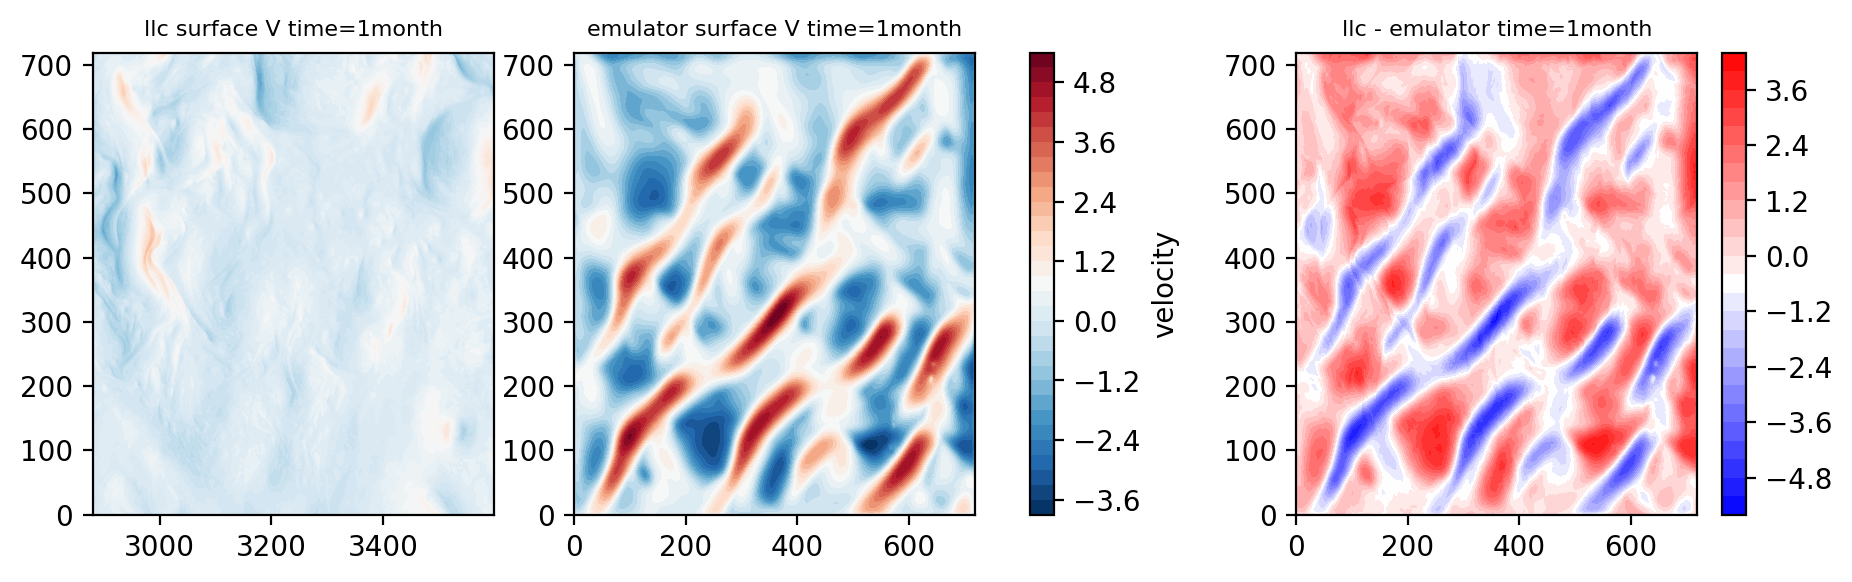

In [9]:
llc_vis = llc_patch.isel(time=1,k=0).V
emulator_vis = emulator_patch.isel(time=1,k=0).V

# Get shared vmin/vmax for llc and emulator
vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="RdBu_r", vmin=vmin, vmax=vmax, levels = 30)
ax1.set_title('llc surface V time=1month', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="RdBu_r", vmin=vmin, vmax=vmax, levels = 30)
ax2.set_title('emulator surface V time=1month', fontsize=8)

# Single colorbar for ax1 and ax2
cbar = plt.colorbar(cf2, ax=[ax1, ax2])
cbar.set_label('velocity')

diff = llc_vis.values - emulator_vis.values
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="bwr", levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1month', fontsize=8)

#plt.tight_layout()
plt.show()

In [10]:
extent = 48
llc_patch = llc_patch_full.isel(time=slice(9216, 9216+extent))
emulator_patch = emulator_patch_full.isel(time=slice(0, extent))

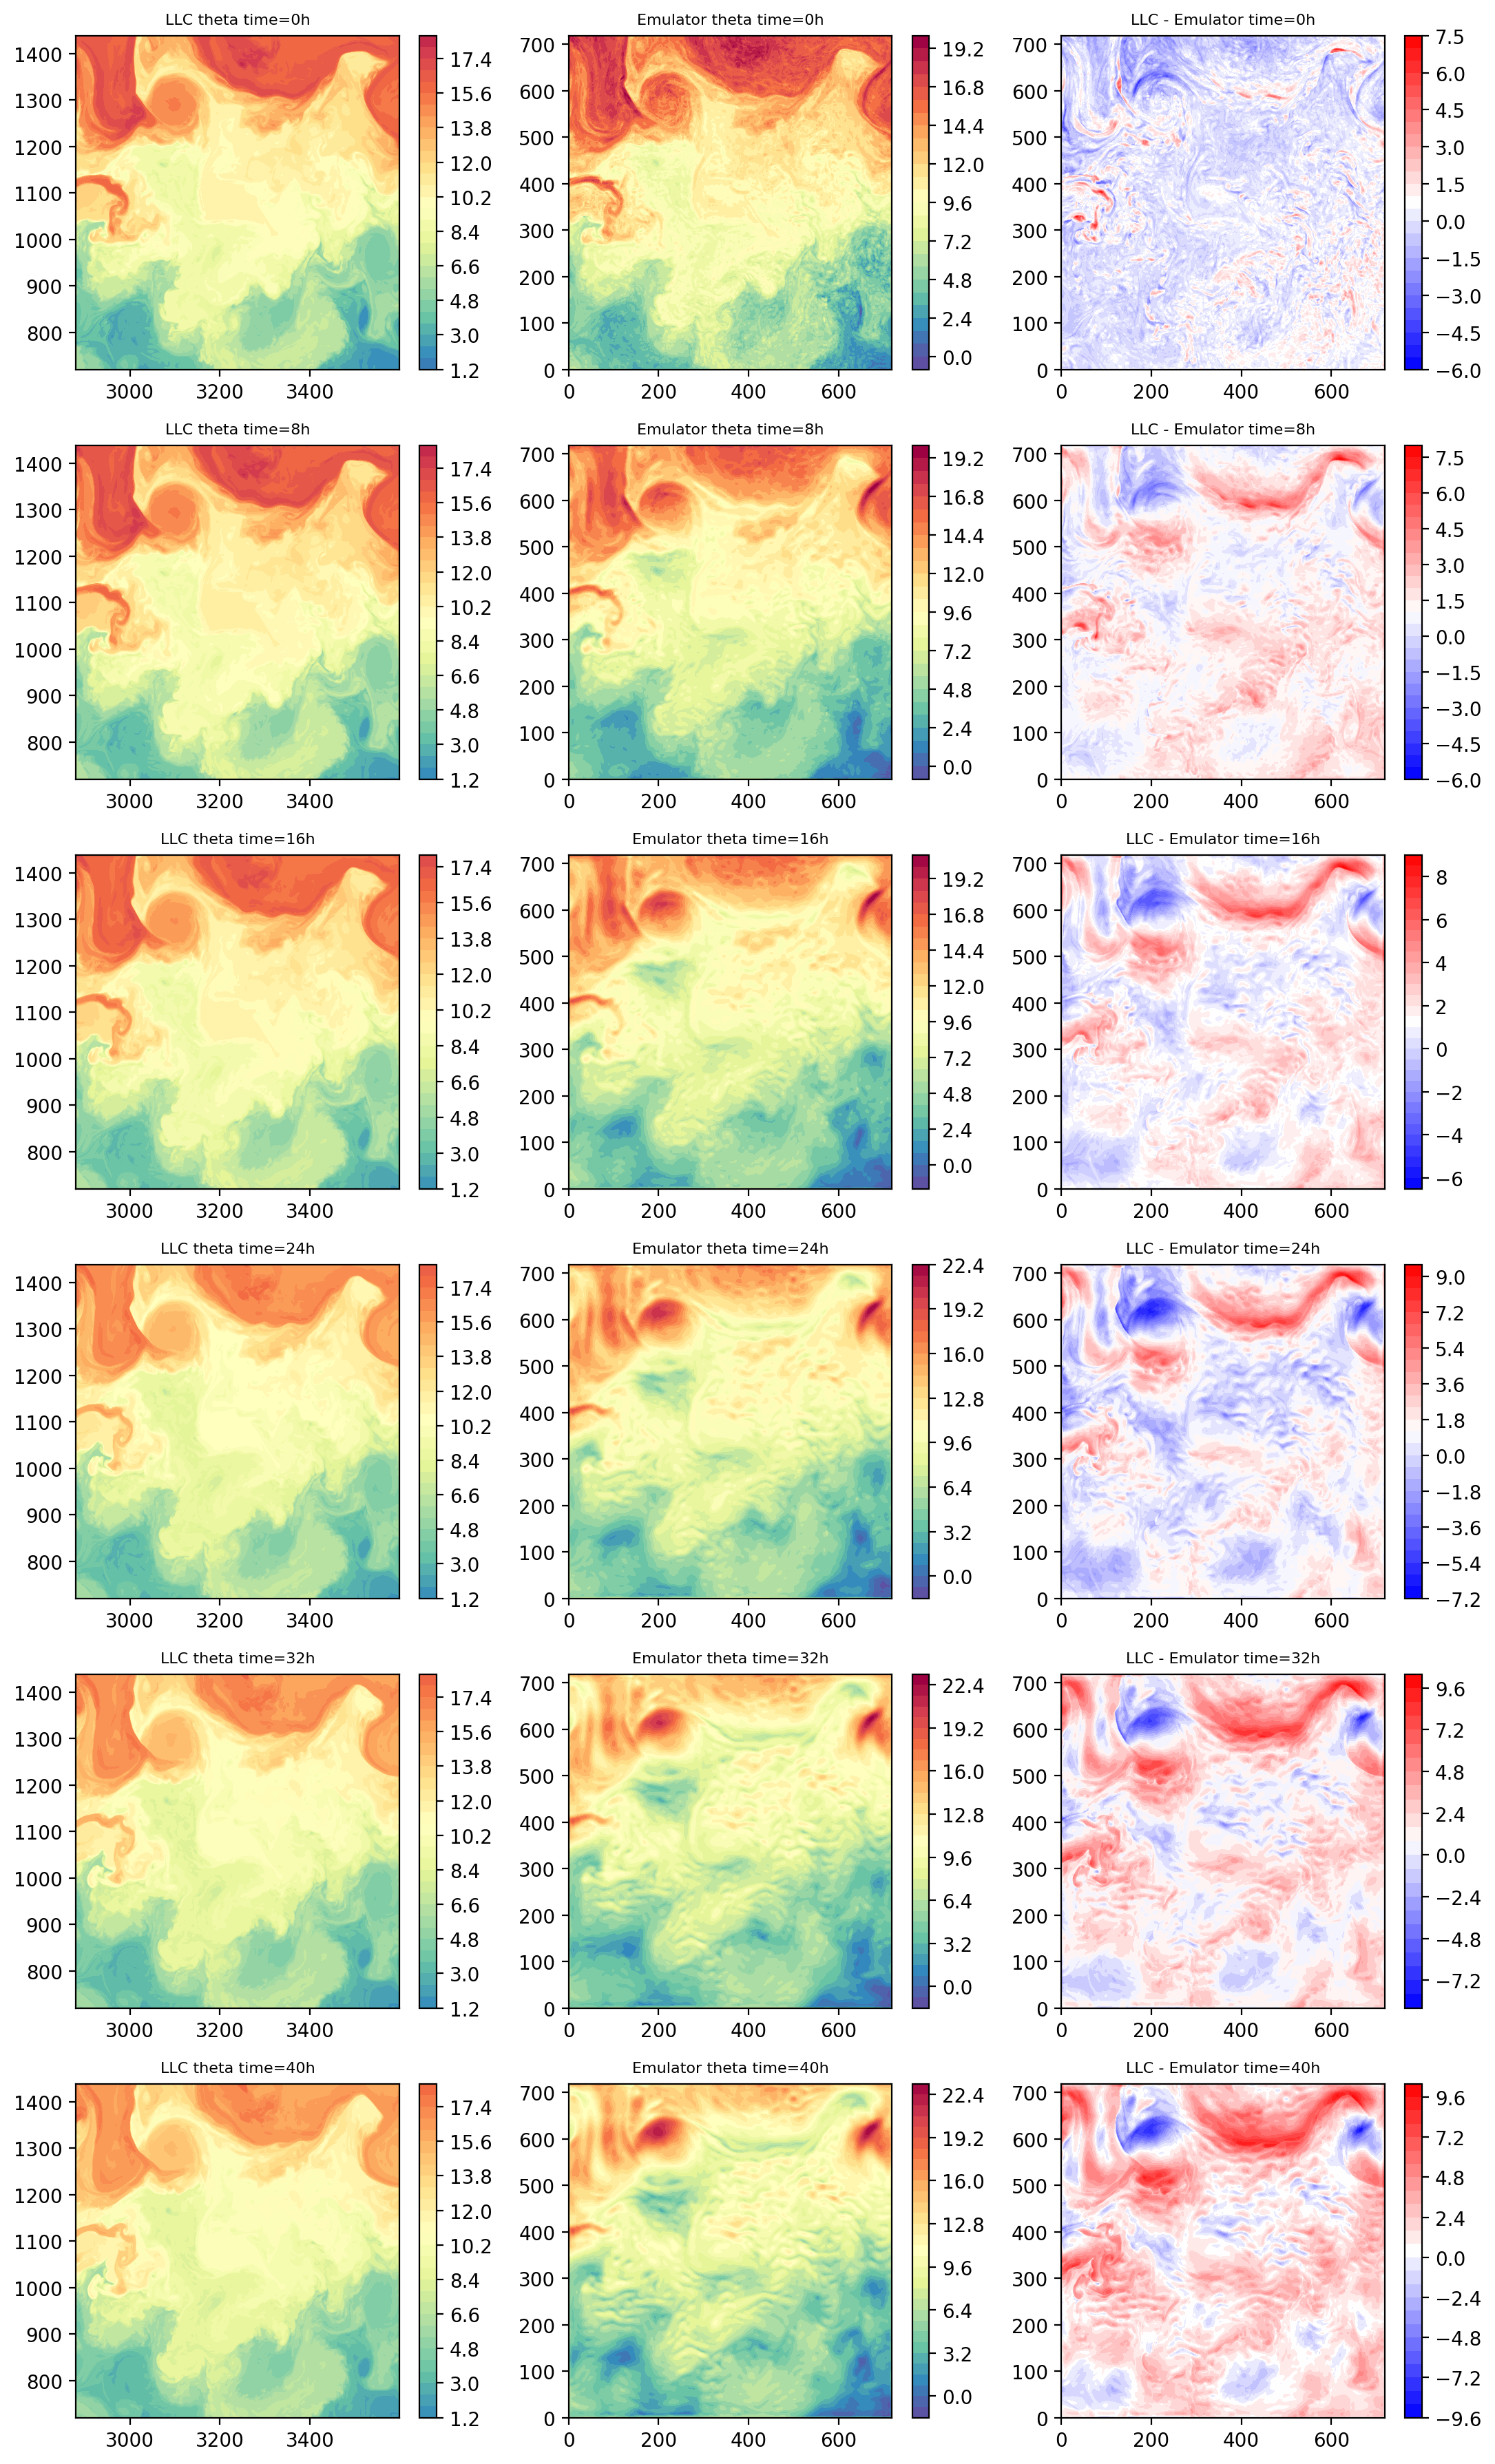

In [14]:
n_times = min(48, len(llc_patch['time']))
time_step = 8  # every 4 hours
time_indices = list(range(0, n_times, time_step))
nrows = len(time_indices)
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3*nrows), dpi=200)

for row, t in enumerate(time_indices):
    llc_vis = llc_patch.isel(time=t, k=0).Theta
    emulator_vis = emulator_patch.isel(time=t, k=0).Theta
    
    # Get shared vmin/vmax for this time step
    vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
    vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])
    
    ax1, ax2, ax3 = axes[row, 0], axes[row, 1], axes[row, 2]
    
    cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
        llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
            cmap="Spectral_r", vmin=vmin, vmax=vmax, levels = 30)
    ax1.set_title(f'LLC theta time={t}h', fontsize=8)
    plt.colorbar(cf1, ax=ax1)
    
    cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
            cmap="Spectral_r", vmin=vmin, vmax=vmax, levels = 30)
    ax2.set_title(f'Emulator theta time={t}h', fontsize=8)
    plt.colorbar(cf2, ax=ax2)
    
    diff = llc_vis.values - emulator_vis.values
    cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
            cmap="bwr", levels = 30)
    ax3.set_title(f'LLC - Emulator time={t}h', fontsize=8)
    plt.colorbar(cf3, ax=ax3)

plt.tight_layout()
plt.savefig('figs/depth-time-snapshots/Theta_time_diff.png')
#plt.show()

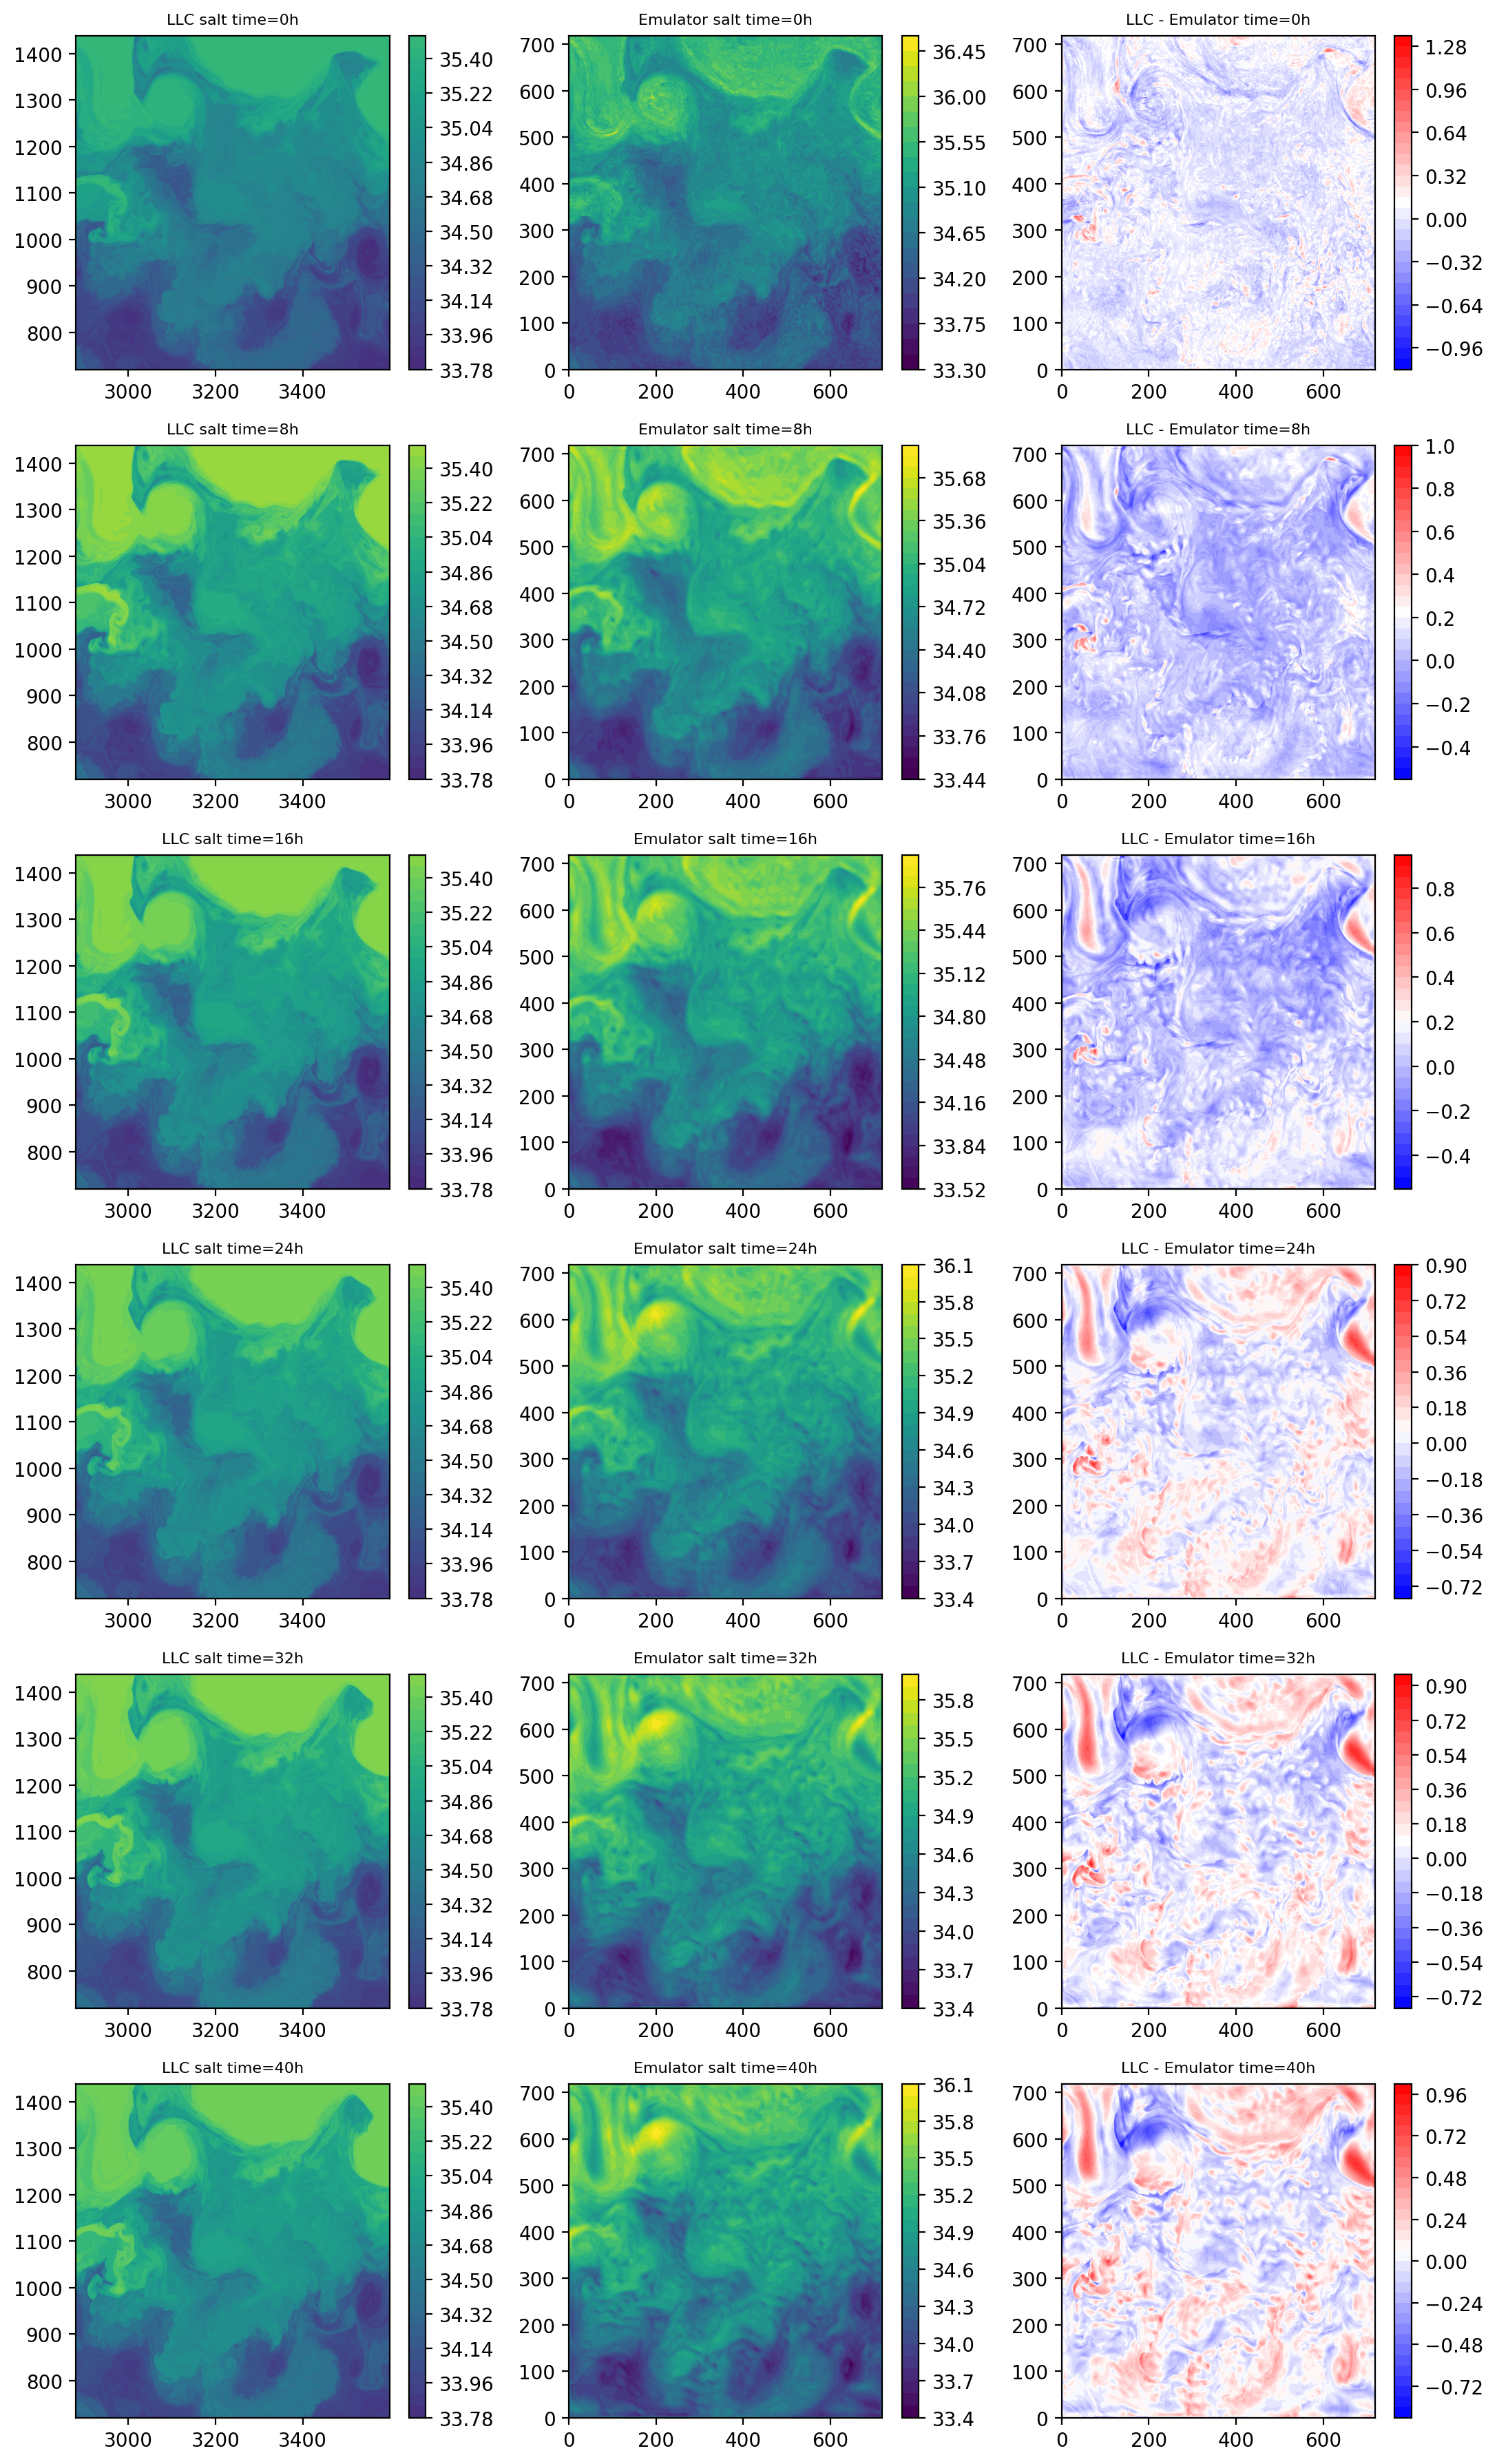

In [15]:
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3*nrows), dpi=200)

for row, t in enumerate(time_indices):
    llc_vis = llc_patch.isel(time=t, k=0).Salt
    emulator_vis = emulator_patch.isel(time=t, k=0).Salt
    
    # Get shared vmin/vmax for this time step
    vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
    vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])
    
    ax1, ax2, ax3 = axes[row, 0], axes[row, 1], axes[row, 2]
    
    cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
        llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
            cmap="viridis", vmin=vmin, vmax=vmax, levels = 30)
    ax1.set_title(f'LLC salt time={t}h', fontsize=8)
    plt.colorbar(cf1, ax=ax1)
    
    cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
            cmap="viridis", vmin=vmin, vmax=vmax, levels = 30)
    ax2.set_title(f'Emulator salt time={t}h', fontsize=8)
    plt.colorbar(cf2, ax=ax2)
    
    diff = llc_vis.values - emulator_vis.values
    cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
            cmap="bwr", levels = 30)
    ax3.set_title(f'LLC - Emulator time={t}h', fontsize=8)
    plt.colorbar(cf3, ax=ax3)

plt.tight_layout()
plt.savefig('figs/depth-time-snapshots/Salt_time_diff.png')
#plt.show()

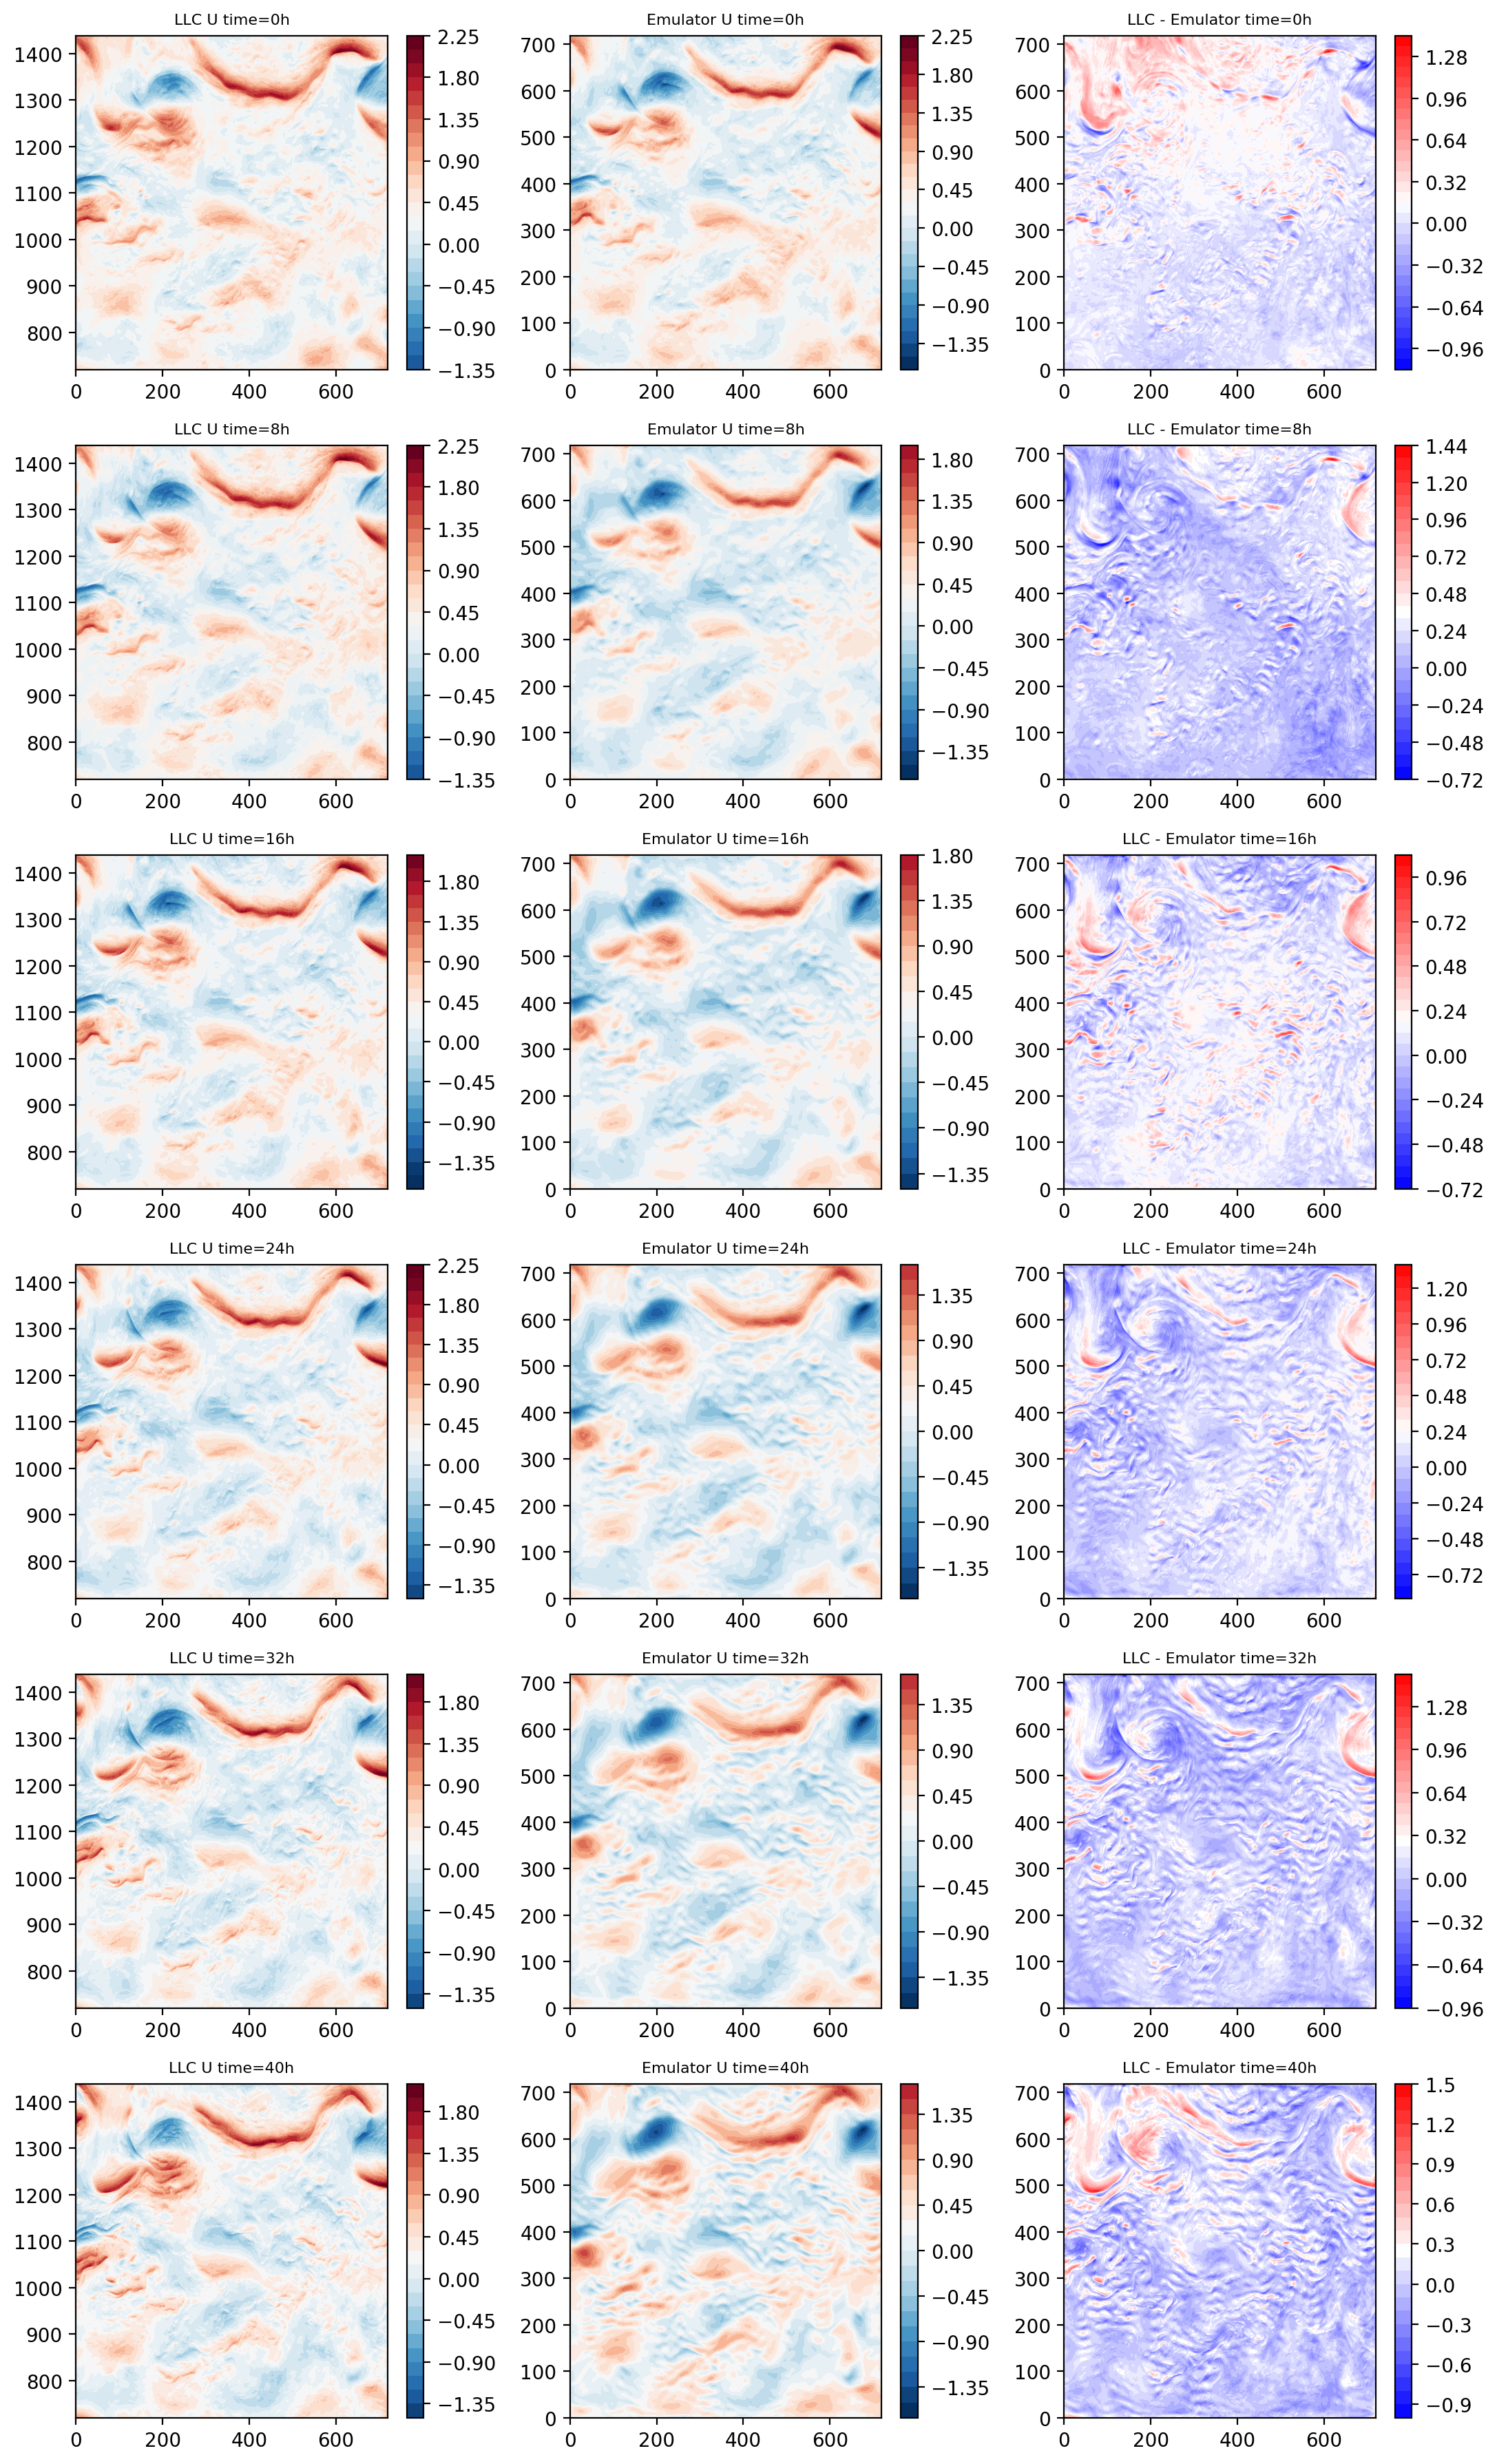

In [17]:
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3*nrows), dpi=200)

for row, t in enumerate(time_indices):
    llc_vis = llc_patch.isel(time=t, k=0).U
    emulator_vis = emulator_patch.isel(time=t, k=0).U
    
    # Get shared vmin/vmax for this time step
    vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
    vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])
    
    ax1, ax2, ax3 = axes[row, 0], axes[row, 1], axes[row, 2]
    
    cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
        llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
            cmap="RdBu_r", vmin=vmin, vmax=vmax, levels = 30)
    ax1.set_title(f'LLC U time={t}h', fontsize=8)
    plt.colorbar(cf1, ax=ax1)
    
    cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
            cmap="RdBu_r", vmin=vmin, vmax=vmax, levels = 30)
    ax2.set_title(f'Emulator U time={t}h', fontsize=8)
    plt.colorbar(cf2, ax=ax2)
    
    diff = llc_vis.values - emulator_vis.values
    cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
            cmap="bwr", levels = 30)
    ax3.set_title(f'LLC - Emulator time={t}h', fontsize=8)
    plt.colorbar(cf3, ax=ax3)

plt.tight_layout()
plt.savefig('figs/depth-time-snapshots/U_time_diff.png')
#plt.show()

In [18]:
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3*nrows), dpi=200)

for row, t in enumerate(time_indices):
    llc_vis = llc_patch.isel(time=t, k=0).V
    emulator_vis = emulator_patch.isel(time=t, k=0).V
    
    # Get shared vmin/vmax for this time step
    vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
    vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])
    
    ax1, ax2, ax3 = axes[row, 0], axes[row, 1], axes[row, 2]
    
    cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
        llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
            cmap="RdBu_r", vmin=vmin, vmax=vmax, levels = 30)
    ax1.set_title(f'LLC V time={t}h', fontsize=8)
    plt.colorbar(cf1, ax=ax1)
    
    cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
            cmap="RdBu_r", vmin=vmin, vmax=vmax, levels = 30)
    ax2.set_title(f'Emulator V time={t}h', fontsize=8)
    plt.colorbar(cf2, ax=ax2)
    
    diff = llc_vis.values - emulator_vis.values
    cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
            cmap="bwr", levels = 30)
    ax3.set_title(f'LLC - Emulator time={t}h', fontsize=8)
    plt.colorbar(cf3, ax=ax3)

plt.tight_layout()
plt.savefig('figs/depth-time-snapshots/V_time_diff.png')
#plt.show()
plt.close()

In [19]:
extent = 9960 - 9216
llc_patch = llc_patch_full.isel(time=slice(9216, 9960))
emulator_patch = emulator_patch_full.isel(time=slice(0, extent))

In [60]:
nrows = 15  # time samples (every 2 days)
ncols = 6   # depth samples
depth_indices = [0, 10, 20, 30, 40, 50]  # equally spaced through 50 depths

# Equally space 31 time samples across available data
n_times = len(emulator_patch['time'])
time_indices = np.linspace(0, n_times - 1, nrows, dtype=int)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2*nrows), dpi=100)

for row, t in enumerate(time_indices):
    for col, k in enumerate(depth_indices):
        emulator_vis = emulator_patch.isel(time=t, k=k).Theta
        
        ax = axes[row, col]
        
        vmin = float(emulator_vis.quantile(0.01))
        vmax = float(emulator_vis.quantile(0.99))
        
        cf = ax.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
            emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
                cmap="Spectral_r", levels=20, vmin=vmin, vmax=vmax)
        
        if col == ncols - 1:
            plt.colorbar(cf, ax=ax)
        
        if row == 0:
            ax.set_title(f'Depth k={k}', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'time={t}h', fontsize=8)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('figs/depth-time-snapshots/Theta_depth_time_progression.png')
#plt.show()
plt.close()

In [77]:
nrows = 15  # time samples (every 2 days)
ncols = 6   # depth samples
depth_indices = [0, 10, 20, 30, 40, 50]  # equally spaced through 50 depths

# Equally space 31 time samples across available data
n_times = len(emulator_patch['time'])
time_indices = np.linspace(0, n_times - 1, nrows, dtype=int)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2*nrows), dpi=100)

for row, t in enumerate(time_indices):
    for col, k in enumerate(depth_indices):
        emulator_vis = emulator_patch.isel(time=t, k=k).Salt
        
        ax = axes[row, col]

        vmin = float(emulator_vis.quantile(0.05))
        vmax = float(emulator_vis.quantile(0.99))
        
        cf = ax.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
            emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
                cmap="viridis", levels=20, vmin=vmin, vmax=vmax)
        
        if col == ncols - 1:
            plt.colorbar(cf, ax=ax)
        
        if row == 0:
            ax.set_title(f'Depth k={k}', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'time={t}h', fontsize=8)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('figs/depth-time-snapshots/Salt_depth_time_progression.png')
#plt.show()
plt.close()

In [ ]:
nrows = 15  # time samples (every 2 days)
ncols = 6   # depth samples
depth_indices = [0, 10, 20, 30, 40, 50]  # equally spaced through 50 depths

# Equally space 31 time samples across available data
n_times = len(emulator_patch['time'])
time_indices = np.linspace(0, n_times - 1, nrows, dtype=int)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2*nrows), dpi=100)

for row, t in enumerate(time_indices):
    for col, k in enumerate(depth_indices):
        emulator_vis = emulator_patch.isel(time=t, k=k).U
        
        ax = axes[row, col]

        vmin = float(emulator_vis.quantile(0.01))
        vmax = float(emulator_vis.quantile(0.99))
        
        cf = ax.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
            emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
                cmap="RdBu_r", levels=20, vmin=vmin, vmax=vmax)
        
        if col == ncols - 1:
            plt.colorbar(cf, ax=ax)
        
        if row == 0:
            ax.set_title(f'Depth k={k}', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'time={t}h', fontsize=8)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('figs/depth-time-snapshots/U_depth_time_progression.png')
#plt.show()
plt.close()

In [ ]:
nrows = 15  # time samples (every 2 days)
ncols = 6   # depth samples
depth_indices = [0, 10, 20, 30, 40, 50]  # equally spaced through 50 depths

# Equally space 31 time samples across available data
n_times = len(emulator_patch['time'])
time_indices = np.linspace(0, n_times - 1, nrows, dtype=int)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2*nrows), dpi=100)

for row, t in enumerate(time_indices):
    for col, k in enumerate(depth_indices):
        emulator_vis = emulator_patch.isel(time=t, k=k).V
        
        ax = axes[row, col]

        vmin = float(emulator_vis.quantile(0.01))
        vmax = float(emulator_vis.quantile(0.99))
        
        cf = ax.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
            emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
                cmap="RdBu_r", levels=20, vmin=vmin, vmax=vmax)
        
        if col == ncols - 1:
            plt.colorbar(cf, ax=ax)
        
        if row == 0:
            ax.set_title(f'Depth k={k}', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'time={t}h', fontsize=8)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('figs/depth-time-snapshots/V_depth_time_progression.png')
#plt.show()
plt.close()